# Exercise 005

<a href="https://colab.research.google.com/github/FAIRChemistry/PythonProgramming2025/blob/master/exercises/Exercise005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Please execute this cell to download the necessary data
!wget https://github.com/JR-1991/PythonProgramming2025/raw/master/data/gc_len_data.csv

--2026-05-15 19:24:05--  https://github.com/JR-1991/PythonProgramming2025/raw/master/data/gc_len_data.csv
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/JR-1991/PythonProgramming2025/master/data/gc_len_data.csv [following]
--2026-05-15 19:24:06--  https://raw.githubusercontent.com/JR-1991/PythonProgramming2025/master/data/gc_len_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3663624 (3.5M) [text/plain]
Saving to: ‘gc_len_data.csv’

gc_len_data.csv     100%[===================>]   3.49M  --.-KB/s    in 0.07s   

2026-05-15 19:24:06 (51.2 MB/s) - ‘gc_len_data.csv’ saved [3663624/3663624

In [2]:
# Please execute this cell to install the necessary packages
%pip install seaborn matplotlib pandas numpy scikit-learn

## Data Clustering #1

Read in the data `gc_len_data.csv` using Pandas, perform KMeans clustering, visualize the result with a suitable plot, and compare it to the original data.

What do you notice? Was the data clustered correctly?

**Tips**

> * To visualize the data, you may want to use a dimensionality reduction method, such as the Principal Component Analysis, to confirm the clustering result visually. Check the Sciki-Learn's documentation for guidance on implementing your own method. If you're having trouble, you can use the implementation from the previous exercise, available [here](https://jr-1991.github.io/PythonProgrammingBio24/solutions/Exercise004/).
> * This dataset consists of various data types, but the clustering method only works with numeric data. Use the `filter` method to narrow down the dataset to columns that are compatible with the algorithm.

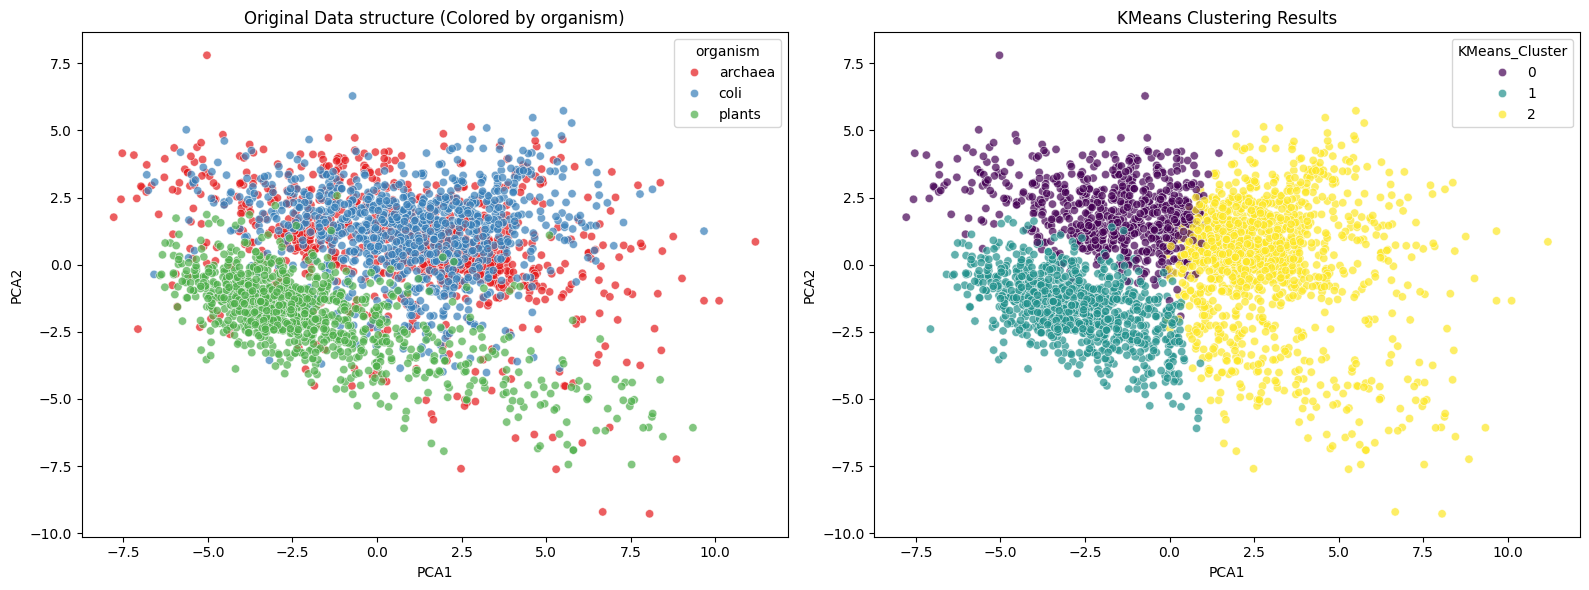

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Read the data
df = pd.read_csv('gc_len_data.csv')

# 2. Filter for numeric columns only (e.g., GC content, length)
numeric_cols = df.select_dtypes(include=[np.number]).columns
X = df[numeric_cols]

# 3. Scale features (Critical for distance-based algorithms like KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Perform KMeans Clustering
# (Assuming 3 clusters as a common starting baseline; adjust if you have a ground truth column)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_transform(X_scaled).argmin(axis=1)

# 5. Dimensionality Reduction using PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# 6. Visualize and Compare
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Original categories (if a label/species/type column exists)
# Replace 'species' or 'label' with your dataset's actual ground-truth column name if available
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
if len(categorical_cols) > 0:
    true_label = categorical_cols[0] # Picks the first non-numeric column
    sns.scatterplot(data=df, x='PCA1', y='PCA2', hue=true_label, palette='Set1', alpha=0.7, ax=axes[0])
    axes[0].set_title(f'Original Data structure (Colored by {true_label})')
else:
    sns.scatterplot(data=df, x='PCA1', y='PCA2', color='gray', alpha=0.5, ax=axes[0])
    axes[0].set_title('Original Data structure (Unlabeled)')

# Plot B: KMeans Clusters
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='viridis', alpha=0.7, ax=axes[1])
axes[1].set_title('KMeans Clustering Results')

plt.tight_layout()
plt.show()

## Data Clustering #2

KMeans is a powerful algorithm for detecting clusters, but it requires prior knowledge and assumes linear decision boundaries. Determining the appropriate number of 'classes' in your dataset can be challenging. Review SciKit-Learn's [documentation](https://scikit-learn.org/stable/modules/clustering.html) on clustering algorithms and try out at least one or two of them to repeat the previous task.

How do they perform? Which one do you prefer and why?

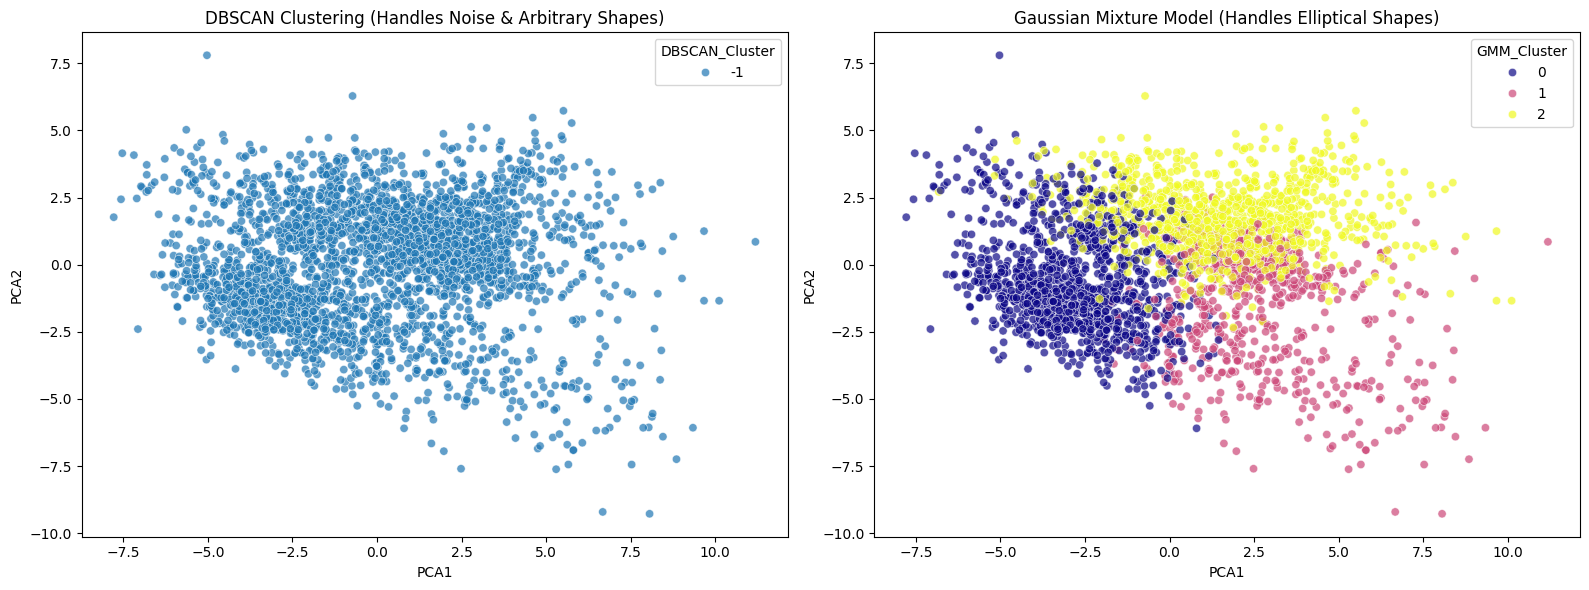

In [4]:
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# 1. DBSCAN (Density-Based: Good for finding non-spherical shapes & filtering noise)
# Adjust eps and min_samples based on how dense your PCA plot looks
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# 2. Gaussian Mixture Models (Soft Clustering: Allows for elongated/elliptical clusters)
gmm = GaussianMixture(n_components=3, random_state=42)
df['GMM_Cluster'] = gmm.fit_predict(X_scaled)

# 3. Plot Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN Plot
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='tab10', alpha=0.7, ax=axes[0])
axes[0].set_title('DBSCAN Clustering (Handles Noise & Arbitrary Shapes)')

# GMM Plot
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='GMM_Cluster', palette='plasma', alpha=0.7, ax=axes[1])
axes[1].set_title('Gaussian Mixture Model (Handles Elliptical Shapes)')

plt.tight_layout()
plt.show()

## Implementing KMeans

Your task is to implement the kmeans function using the provided helper functions. The kmeans function should take the input data points, the number of clusters, the maximum number of iterations, and the tolerance for convergence as arguments. It should return the final centroids and the labels assigned to each data point. The implementation is outlined as follows:

1. Initialize centroids

    * Use the `initialize_centroids` function to randomly select initial centroids from the data points.

2. Iterate until convergence or maximum iterations:

    * In each iteration
        * Assign labels to each data point based on the nearest centroid using the assign_labels function.
        * Compute new centroids as the mean of all points assigned to each cluster using the compute_centroids function.
        * Check for convergence using the has_converged function.
        * If converged, break the loop.

3. Return results:
    * Return the final centroids and the labels assigned to each data point.

### Helper functions

Execute the following cell to make use of the helper functions.

In [5]:
import numpy as np


def initialize_centroids(X, n_clusters):
    """
    Randomly initialize centroids from the data points.

    Args:
        X (numpy.ndarray): The input data points.
        n_clusters (int): The number of clusters.

    Returns:
        numpy.ndarray: The initialized centroids.
    """
    np.random.seed(42)
    random_indices = np.random.permutation(X.shape[0])
    centroids = X[random_indices[:n_clusters]]
    return centroids


def assign_labels(X, centroids):
    """
    Assign labels to each data point based on the nearest centroid.

    Args:
        X (numpy.ndarray): The input data points.
        centroids (numpy.ndarray): The current centroids.

    Returns:
        numpy.ndarray: The labels assigned to each data point.
    """
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)
    return labels


def compute_centroids(X, labels, n_clusters):
    """
    Compute new centroids as the mean of all points assigned to each cluster.

    Args:
        X (numpy.ndarray): The input data points.
        labels (numpy.ndarray): The labels assigned to each data point.
        n_clusters (int): The number of clusters.

    Returns:
        numpy.ndarray: The new centroids.
    """
    centroids = np.zeros((n_clusters, X.shape[1]))
    for k in range(n_clusters):
        cluster_points = X[labels == k]
        if len(cluster_points) > 0:
            centroids[k] = np.mean(cluster_points, axis=0)
    return centroids


def has_converged(old_centroids, new_centroids, tol):
    """
    Check if the centroids have converged.

    Args:
        old_centroids (numpy.ndarray): The old centroids.
        new_centroids (numpy.ndarray): The new centroids.
        tol (float): The tolerance for convergence.

    Returns:
        bool: True if the centroids have converged, False otherwise.
    """
    return np.all(np.abs(old_centroids - new_centroids) < tol)

In [10]:
def kmeans(df, n_clusters=3, max_iter=300, tol=1e-4):
    """
    Apply the KMeans clustering algorithm.

    Args:
        X (numpy.ndarray): The input data points.
        n_clusters (int): The number of clusters.
        max_iter (int): The maximum number of iterations.
        tol (float): The tolerance for convergence.

    Returns:
        tuple: The final centroids and the labels assigned to each data point.
    """

    # Leave this to convert the DataFrame to NumPy
    X = df.select_dtypes(include="number")

def kmeans(df, n_clusters=3, max_iter=300, tol=1e-4):
    """
    Apply the KMeans clustering algorithm.

    Args:
        df (pd.DataFrame): The input data points inside a DataFrame.
        n_clusters (int): The number of clusters.
        max_iter (int): The maximum number of iterations.
        tol (float): The tolerance for convergence.

    Returns:
        tuple: The final centroids and the labels assigned to each data point.
    """

    # Leave this to convert the DataFrame to NumPy
    X = df.select_dtypes(include="number").values

    # 1. Initialize centroids
    centroids = initialize_centroids(X, n_clusters)

    # Initialize labels variable to ensure scope coverage
    labels = np.zeros(X.shape[0])

    # 2. Iterate until convergence or maximum iterations
    for _ in range(max_iter):
        old_centroids = centroids.copy()

        # Assign labels to each data point based on the nearest centroid
        labels = assign_labels(X, centroids)

        # Compute new centroids as the mean of all points assigned to each cluster
        centroids = compute_centroids(X, labels, n_clusters)

        # Check for convergence
        if has_converged(old_centroids, centroids, tol):
            break

    # 3. Return results
    return centroids, labels